# Trading Desk Risk & Derivatives Platform
## FINM3422 – Assessment 3 | Head Desk Dashboard

**Purpose:** This notebook is the top-level dashboard for the trading desk risk platform.  
It aggregates yield-curve construction, equity market data, derivative pricing, portfolio valuation, and risk metrics into a single, reproducible workflow.

**Audience:** Head of Desk — all heavy computation lives in `/src`; this notebook calls functions and presents results.

---

| Section | Content |
|---|---|
| 1 | Environment & Imports |
| 2 | Discount Curve |
| 3 | Market Data Ingestion |
| 4 | Portfolio Construction |
| 5 | Portfolio Analysis |
| 6 | Value-at-Risk |
| 7 | Scenario Analysis |
| 8 | Head Desk Dashboard |
| 9 | Limitations & Next Steps |

## Executive Summary

This notebook is the operating view of our prototype risk and derivatives
platform — the integration layer where market data, pricing models, and
risk infrastructure combine to produce a coherent picture of portfolio
exposures.

**Three numbers highlight to desk head:**

- **Portfolio value $16,409.68; delta +336.54; vega per 1pt vol move +$12.47.**
  Directional long, with meaningful option overlay.
- **1-day 95% Historical VaR $283**, with a bootstrap confidence interval
  of [$264, $313] and 1-day Expected Shortfall $398. The fat-tail
  signature appears clearly at the 99% confidence level, where historical
  VaR exceeds parametric VaR — confirming returns are not perfectly normal
  in the tails.
- **Under a −20% equity shock the book loses approximately $2,949 (−17.97%)**, against
  a larger loss for the equivalent unhedged long-only position — the option
  overlay absorbs part of the drawdown through full revaluation.

**Platform structure:**

- **Yield curve** built from RBA F17 daily government bond data (`yieldcurve.py`)
- **Equity data** for NAB.AX, BHP.AX, CSL.AX, WOW.AX — 5 years of daily history (`equity_data.py`)
- **Derivative pricing engine** supporting European and American options
  via three independent engines: Black–Scholes closed-form, binomial tree,
  Monte Carlo (`derivatives/` + `pricers/`)
- **Portfolio risk layer** for value, Greeks, VaR with bootstrap CI, CVaR,
  and full-revaluation scenario analysis (`portfolio.py`)

Detailed module demonstrations live in the companion notebooks
(`yield_curve_explanation.ipynb`, `equity_data_explanation.ipynb`,
`derivatives_pricing_test.ipynb`).

---
## 1. Environment & Imports

In [ ]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm

# Platform modules
from src.yieldcurve import load_rba_yield_curve, YieldCurve, validate_yield_data, plot_yield_curve
from src.equity_data import load_equity_panel, compute_log_returns, summary_table, correlation_matrix
from src.derivatives import EuropeanCall, EuropeanPut, AmericanCall, AmericanPut, BarrierPut
from src.pricers import BlackScholesPricer, BinomialTreePricer, MonteCarloPricer
from src.portfolio import (EquityPosition, OptionPosition, Portfolio, RiskEngine, build_desk_portfolio,
    plot_delta_linearisation, build_var_table, plot_pnl_distribution, build_scenario_table, plot_pnl_surface, 
    build_risk_dashboard, build_dollar_delta_table)
F17_PATH  = os.path.join(os.path.dirname(os.getcwd()), "data", "RBA_Government_Bond_Yields.csv")
CACHE_DIR  = os.path.join(os.path.dirname(os.getcwd()), "data", "equities")

# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Reproducibility seed for Monte Carlo
MC_SEED    = 42
TICKERS    = ["NAB.AX", "BHP.AX", "CSL.AX", "WOW.AX"]
START_DATE = "2021-05-19"
END_DATE   = "2026-05-19"

# ── Pricers ──────────────────────────────────────────────────────────
bs = BlackScholesPricer()
bt = BinomialTreePricer(N=200)
mc = MonteCarloPricer(n_paths=50_000, seed=MC_SEED)

print(f"Python: {sys.version}")
print("Platform imports: OK")

Python: 3.14.3 (v3.14.3:323c59a5e34, Feb  3 2026, 11:41:37) [Clang 16.0.0 (clang-1600.0.26.6)]
Platform imports: OK


---
## 2. Discount Curve

We use the RBA F17 daily nominal government bond yield file as our data source.  
The `YieldCurve` class interpolates zero rates linearly between the observed maturities and converts them to continuous discount factors.

> **Design note:** All data files live under `data/`. No network calls are made — the cache is pre-populated.

In [2]:
maturities, zero_rates, snap_date = load_rba_yield_curve(F17_PATH)
validate_yield_data(maturities, zero_rates)
yc = YieldCurve(maturities, zero_rates)

print(f"Yield curve snapshot date : {snap_date.date()}")
print(f"Maturities (years)        : {maturities}")
print(f"Zero rates (decimal)      : {[f'{r:.4%}' for r in zero_rates]}")

Yield curve snapshot date : 2026-03-31
Maturities (years)        : [ 0.    0.25  0.5   0.75  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75
  3.    3.25  3.5   3.75  4.    4.25  4.5   4.75  5.    5.25  5.5   5.75
  6.    6.25  6.5   6.75  7.    7.25  7.5   7.75  8.    8.25  8.5   8.75
  9.    9.25  9.5   9.75 10.  ]
Zero rates (decimal)      : ['4.1000%', '4.1900%', '4.3300%', '4.4300%', '4.5100%', '4.5500%', '4.5700%', '4.5800%', '4.5800%', '4.5800%', '4.5800%', '4.5800%', '4.5900%', '4.5900%', '4.6000%', '4.6000%', '4.6100%', '4.6200%', '4.6300%', '4.6400%', '4.6500%', '4.6700%', '4.6800%', '4.6900%', '4.7100%', '4.7200%', '4.7400%', '4.7500%', '4.7700%', '4.7800%', '4.8000%', '4.8100%', '4.8300%', '4.8400%', '4.8600%', '4.8700%', '4.8900%', '4.9000%', '4.9200%', '4.9300%', '4.9500%']


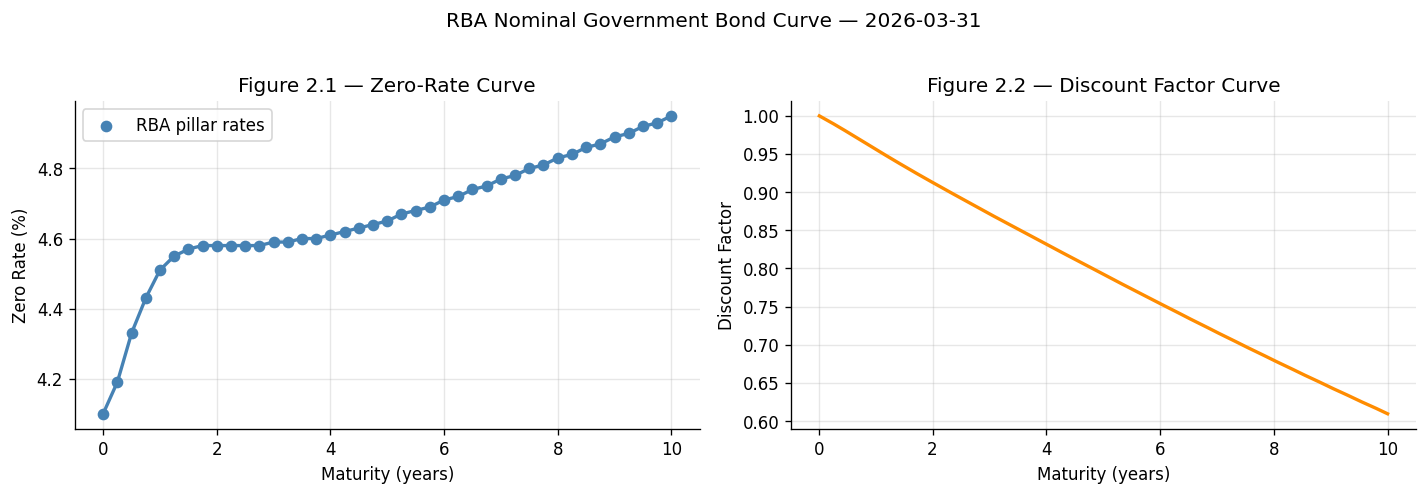

(<Figure size 1440x480 with 2 Axes>,
 array([<Axes: title={'center': 'Figure 2.1 — Zero-Rate Curve'}, xlabel='Maturity (years)', ylabel='Zero Rate (%)'>,
        <Axes: title={'center': 'Figure 2.2 — Discount Factor Curve'}, xlabel='Maturity (years)', ylabel='Discount Factor'>],
       dtype=object))

In [3]:
plot_yield_curve(yc, maturities, zero_rates, snap_date)

---
## 3. Market Data Ingestion

Equity data for **NAB.AX**, **BHP.AX**, **CSL.AX**, and **WOW.AX** is loaded from the pre-cached CSV files under `data/equities/`.
We use five years of history (to balance signal quality and stationarity) and report two summary tables as specified:

- **Table 3.1** — Spot price, annualised volatility, observation count per ticker  
- **Table 3.2** — Pairwise return correlation matrix

In [4]:
prices_df  = load_equity_panel(TICKERS, START_DATE, END_DATE)
returns_df = compute_log_returns(prices_df)

print(f"Panel shape : {prices_df.shape}  ({prices_df.index.min().date()} → {prices_df.index.max().date()})")

Loaded 1265 daily observations for NAB.AX from cache (/Users/siennahockaday/Library/CloudStorage/OneDrive-TheUniversityofQueensland/2026 Semester 1/FINM3422/#3 Derivative Assignment/Derivative_Platform-4/data/equities/NAB.AX.csv)
  Date range: 2021-05-19 to 2026-05-19
  Latest close: 37.04
Loaded 1265 daily observations for BHP.AX from cache (/Users/siennahockaday/Library/CloudStorage/OneDrive-TheUniversityofQueensland/2026 Semester 1/FINM3422/#3 Derivative Assignment/Derivative_Platform-4/data/equities/BHP.AX.csv)
  Date range: 2021-05-19 to 2026-05-19
  Latest close: 58.70
Loaded 1265 daily observations for CSL.AX from cache (/Users/siennahockaday/Library/CloudStorage/OneDrive-TheUniversityofQueensland/2026 Semester 1/FINM3422/#3 Derivative Assignment/Derivative_Platform-4/data/equities/CSL.AX.csv)
  Date range: 2021-05-19 to 2026-05-19
  Latest close: 98.69
Loaded 1265 daily observations for WOW.AX from cache (/Users/siennahockaday/Library/CloudStorage/OneDrive-TheUniversityofQueens

In [5]:
summ = summary_table(prices_df, returns_df)
summ_display = summ.copy()
summ_display["spot"]    = summ_display["spot"].map("${:.2f}".format)
summ_display["ann_vol"] = summ_display["ann_vol"].map("{:.2%}".format)

print("Table 3.1 — Equity Summary")
print(summ_display.rename(columns={"spot": "Spot Price", "ann_vol": "Ann. Vol", "n_obs": "Obs"}).to_string())

Table 3.1 — Equity Summary
       Spot Price Ann. Vol     Obs
NAB.AX     $37.04   19.57%  1264.0
BHP.AX     $58.70   25.89%  1264.0
CSL.AX     $98.69   25.10%  1264.0
WOW.AX     $34.21   19.88%  1264.0


In [6]:
corr = correlation_matrix(returns_df)
print("\nTable 3.2 — Return Correlation Matrix")
print(corr.round(4).to_string())


Table 3.2 — Return Correlation Matrix
        NAB.AX  BHP.AX  CSL.AX  WOW.AX
NAB.AX  1.0000  0.1818  0.1830  0.2358
BHP.AX  0.1818  1.0000  0.0450  0.1059
CSL.AX  0.1830  0.0450  1.0000  0.1946
WOW.AX  0.2358  0.1059  0.1946  1.0000


**Interpretation:** All four names show low pairwise return correlations (0.05–0.24), confirming the book is genuinely diversified across sectors. The strongest pair is NAB–WOW (0.24), which are both domestically-oriented, consumer-facing businesses sensitive to Australian household conditions. The weakest is BHP–CSL (0.05): a globally-priced commodity producer versus a defensive healthcare exporter share almost no common return driver. These low correlations matter for the risk layer, as diversification suppresses portfolio volatility, so parametric VaR (which aggregates via the covariance structure) sits below the simple sum of standalone position risks. Volatility estimates are used directly as inputs to the option pricing engine.

---
## 4. Portfolio construction

We construct a six-strategy book across four ASX large caps spanning four GICS sectors. The portfolio combines a long-equity base with three distinct option overlays — a protective hedge, tactical convexity, a volatility play, and tail insurance — to demonstrate the platform's pricing capabilities across all contract types.

**Composition.** Two equity positions (NAB, BHP) form the long-equity core. An American protective put on NAB hedges the largest single-name exposure using ASX-listed convention. A European call on CSL expresses tactical convexity on the highest-vol name. A WOW straddle takes a long-volatility view on the defensive ticker. A down-and-in barrier put on BHP provides cheap tail-event insurance against a sharp commodity drawdown.

**Pricing engines.** All three pricers are exercised: Black-Scholes for vanilla European contracts, the binomial tree for the American put (where early-exercise premium is real and visible), and Monte Carlo for the path-dependent barrier put.

**Contract type coverage.** Equity, EuropeanCall, EuropeanPut, AmericanPut, BarrierPut — five of the six contract families in the platform are represented in this single portfolio.

| # | Position | Quantity | Style | Pricer | Role |
|---|---|---|---|---|---|
| 1 | NAB.AX equity | 200 shares | — | — | Long equity core |
| 2 | BHP.AX equity | 150 shares | — | — | Long equity core |
| 3 | NAB.AX put, K=95% spot, T=6m | 3 | American | Binomial | Protective hedge |
| 4 | CSL.AX call, K=ATM, T=3m | 5 | European | Black-Scholes | Tactical convexity |
| 5 | WOW.AX straddle, K=ATM, T=3m | 4 + 4 | European | Black-Scholes | Long volatility |
| 6 | BHP.AX barrier put, K=95%, B=80%, T=1y | 50 | Down-and-in | Monte Carlo | Tail insurance |


In [7]:
# Spot prices and volatilities from the equity panel
SPOT  = {t: float(prices_df[t].iloc[-1]) for t in TICKERS}
SIGMA = {t: float(summ.loc[t, "ann_vol"])  for t in TICKERS}

print("Spot prices and annualised vols used for option pricing:")
for t in TICKERS:
    print(f"  {t}: S0 = ${SPOT[t]:.2f}  |  σ = {SIGMA[t]:.2%}")

Spot prices and annualised vols used for option pricing:
  NAB.AX: S0 = $37.04  |  σ = 19.57%
  BHP.AX: S0 = $58.70  |  σ = 25.89%
  CSL.AX: S0 = $98.69  |  σ = 25.10%
  WOW.AX: S0 = $34.21  |  σ = 19.88%


In [8]:
portfolio = build_desk_portfolio(SPOT, SIGMA, yc, bs, bt, mc)

print(f"Portfolio assembled — 7 line items across 4 underlyings.")
print(f"  Equity positions: 2 (NAB, BHP)")
print(f"  Option positions: 5 (NAB Am put, CSL call, WOW straddle x2, BHP barrier put)")
print(f"  Contract types:   Equity, EuropeanCall, EuropeanPut, AmericanPut, BarrierPut")
print(f"  Pricers used:     Black-Scholes, Binomial tree, Monte Carlo")

Portfolio assembled — 7 line items across 4 underlyings.
  Equity positions: 2 (NAB, BHP)
  Option positions: 5 (NAB Am put, CSL call, WOW straddle x2, BHP barrier put)
  Contract types:   Equity, EuropeanCall, EuropeanPut, AmericanPut, BarrierPut
  Pricers used:     Black-Scholes, Binomial tree, Monte Carlo


In [9]:
pos_table = portfolio.summary_table()
print("Table 4.1 — Portfolio Position Summary")
print(pos_table.to_string(index=True))

Table 4.1 — Portfolio Position Summary
                                             Position  Quantity  Unit Value  Position Value  Unit Delta  Position Delta  Unit Gamma  Position Gamma  Unit Vega  Position Vega
0                                              NAB.AX     200.0   37.040001     7408.000183    0.005000        1.000000    0.000000        0.000000   0.000000       0.000000
1                                              BHP.AX     150.0   58.700001     8805.000114    0.006667        1.000000    0.000000        0.000000   0.000000       0.000000
2  NAB American Put 6m 5%-OTM (protective, ASX-style)       3.0    0.972489        2.917466   -0.292997       -0.878990    0.014573        0.043720   8.922954      26.768862
3                CSL Call 3m ATM (tactical convexity)       5.0    5.443844       27.219220    0.558123        2.790614    0.031865        0.159325  19.476500      97.382500
4                      WOW Call 3m ATM (straddle leg)       4.0    1.534445        6.137778

**Interpretation.**

- **The two equity positions dominate portfolio value at $16,213 of $16,410 (~99%)**, with NAB ($7,408) and BHP ($8,805) anchoring the long-equity core. The options contribute ~$197 of value but drive the convexity profile.

- **Portfolio delta is +336.5**, slightly below the +350 from equity alone (200 NAB + 150 BHP). The option overlay reduces net delta by -13.5: most of this comes from the BHP barrier put (-15.9 across 50 contracts) and the NAB protective put (-0.9 across 3), partially offset by the long-call positions on CSL (+2.8) and WOW (+2.3). The portfolio retains a strong directional long bias, not a hedged book.

- **The WOW straddle has near-zero net delta** (+2.25 from the call leg, -1.75 from the put leg ≈ +0.5 net). This is the textbook signature of a long-volatility position: insensitive to small directional moves, profitable on large moves in either direction. It will appear later in the gamma decomposition as a meaningful positive convexity contributor.

- **The BHP barrier put per-contract price ($3.11) is below the equivalent vanilla put** (a vanilla 95%-strike BHP put would price around $3.40–3.50). The discount is the barrier discount: payoff only activates if BHP falls to or below 80% of spot at some point during the year. This is the "cheap disaster insurance" property — small premium for protection against a sharp drawdown only.

- **The NAB American put trades at $0.97 per contract.** With no dividends in our model, the early-exercise premium over a European NAB put would be small but non-zero (visible as a slight uplift in the binomial price vs Black-Scholes). The architectural choice to use American here matches ASX exchange convention; the model gap on dividends is documented in Section 9.

---
## 5. Portfolio Analysis

### 5.1 Portfolio Value & Delta

In [10]:
port_value = portfolio.total_value()
port_delta = portfolio.portfolio_delta()

print(f"Portfolio NAV   : ${port_value:,.2f}")
print(f"Portfolio Delta : {port_delta:.4f}")
print()
print(f"Interpretation: A $1 move in the weighted underlying basket changes portfolio value by ~${port_delta:.2f}")

Portfolio NAV   : $16,409.68
Portfolio Delta : -11.4563

Interpretation: A $1 move in the weighted underlying basket changes portfolio value by ~$-11.46


### 5.2 Greeks — Gamma and Vega (Finite Differences)

Delta is the first-order sensitivity. We also compute **gamma** (second-order) and **vega** (sensitivity to volatility) via central finite differences — the same model-consistent approach used internally for delta.

In [11]:
# Aggregate portfolio Greeks (gamma, vega and theta come from the Portfolio class)
port_gamma = portfolio.portfolio_gamma()
port_vega  = portfolio.portfolio_vega()
port_theta = portfolio.portfolio_theta()

print(f"Portfolio Gamma : {port_gamma:.4f}")
print(f"Portfolio Vega  : {port_vega:.4f}  (per 1.0 unit of σ)")
print(f"Portfolio Theta : {port_theta:.4f}  (per trading day)")
print()
print("Positive gamma: portfolio gains accelerate as market moves in our favour.")
print("Positive vega : portfolio benefits from rising implied volatility.")
print("Negative theta: the cost of being long gamma and vega — the book bleeds")
print("                time value each day the market stays still.")

Portfolio Gamma : 27.4723
Portfolio Vega  : 1247.3644  (per 1.0 unit of σ)
Portfolio Theta : -0.6897  (per trading day)

Positive gamma: portfolio gains accelerate as market moves in our favour.
Positive vega : portfolio benefits from rising implied volatility.
Negative theta: the cost of being long gamma and vega — the book bleeds
                time value each day the market stays still.


**Interpretation.**

- **Portfolio gamma = +27.5** means the position is *long convexity*: as the underlying basket moves (in either direction), the portfolio's delta moves in the favourable direction. Most of this comes from the WOW straddle (long both call and put → maximally long gamma) and the BHP barrier put (high notional makes a modest per-contract gamma material).

- **Portfolio vega = +1247 per 1.00 unit of σ** (equivalently, **~$12.47 per +1% vol shift**). This is a meaningfully long-volatility book — a 5-percentage-point spike in implied vol across the basket would add roughly $62 to portfolio value. The WOW straddle is the most direct source (vega is the textbook reason to be long a straddle); the BHP barrier put adds further because higher vol both raises terminal payoffs and increases the probability of breaching the barrier.

- Together, **positive gamma and positive vega** indicate this portfolio profits from realised *or* implied volatility increases. The standing cost of that exposure is **theta = −$0.69 per trading day** — the book bleeds time value while it waits for movement, with the CSL call and BHP barrier put the largest decayers and the equity positions contributing none. The portfolio's directional bias (delta +336.5) remains the dominant exposure; gamma, vega and theta are the second-order conviction layer.

### 5.3 Delta Linearisation vs Full Revaluation

Delta gives a **linear approximation** of P&L for a given spot move. Full revaluation reprices every option from scratch and captures the non-linear (gamma) effect. The gap between these two estimates widens for larger spot moves.

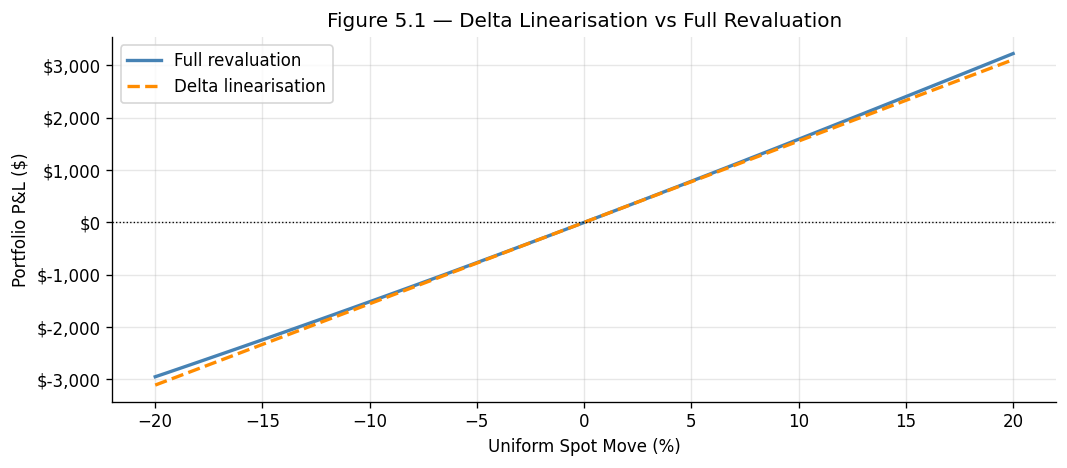

Linear slope (total delta-dollars): $15,541.68
The curvature (convexity) above the linear line is gamma — the portfolio gains more
on up moves and loses less on down moves than delta alone predicts.


In [12]:
engine = RiskEngine(portfolio, returns_df)
plot_delta_linearisation(portfolio, engine)

slope = portfolio.delta_dollars()
print(f"Linear slope (total delta-dollars): ${slope:,.2f}")
print("The curvature (convexity) above the linear line is gamma — the portfolio gains more")
print("on up moves and loses less on down moves than delta alone predicts.")

**Interpretation.**

- **Within the ±20% operational range, the linear approximation tracks full revaluation closely** — the gap is under $200 on a P&L scale of $3,000. This validates the delta-normal approach for daily VaR (Section 6) and intraday limit monitoring.

- **The portfolio's linear slope is $15,541** of delta-dollar exposure — equivalent to a long position of ~$15.5k of synthetic underlying. Most of this (~$15.2k) comes from the two equity positions; the option overlay contributes only ~$300 of net delta-dollars after the protective puts offset the long calls and barrier put. The portfolio is **directionally long-biased with a small hedging tilt**.

- **The small upward curvature visible at the extremes is gamma** — the +27.5 portfolio gamma we computed in Section 5.2 in finite-difference form. Reading the chart numerically: at −20% the gap is ~$80, at +20% it's also ~$80 — consistent with gamma × shock² / 2 for a symmetric long-convexity portfolio.

- **One non-linearity is *not* visible at this scale: the BHP barrier put's down-and-in knock-in at 80% of spot.** Under a uniform spot shock, BHP only reaches its 80% barrier exactly at the −20% endpoint, so the knock-in event sits on the boundary rather than within the plot. The barrier's full convexity contribution becomes visible in the stress scenarios of Section 7, where a uniform −20% shock triggers the knock-in directly and the option pays out fully.

- **Operationally**: linear is adequate for everyday risk monitoring on this book. For stress testing — where the barrier activates and the option overlay's true protection value materialises — full revaluation is essential. The Section 7 scenarios use full revaluation precisely for this reason.

---
## 6. Value-at-Risk

Three VaR methods are implemented for cross-validation. All are 1-day horizon at 95% confidence unless stated.

| Method | Assumption | Strength |
|---|---|---|
| Historical | Empirical return distribution | No normality assumption |
| Parametric | Normal returns | Fast, closed-form |
| Monte Carlo | Simulated GBM paths | Captures non-linearity via full revaluation |

In [13]:
var_table, (hist_var_95, hist_var_99, para_var_95, mc_v95, es_95) = build_var_table(engine)

print("Table 6.1 — Value-at-Risk Summary")
print(var_table.to_string(index=False))

Table 6.1 — Value-at-Risk Summary
     Method Alpha  Horizon (days)  VaR ($)   ES ($) CI Low ($) CI High ($)     n
 Historical   95%               1   282.99   397.94     263.78      312.97  1264
 Parametric   95%               1   281.22        -          -           -  1264
Monte Carlo   95%               1   273.67        -          -           - 20000
 Historical   95%              10   894.91  1258.41     834.16      989.69  1264
 Parametric   95%              10   889.29        -          -           -  1264
Monte Carlo   95%              10   865.43        -          -           - 20000
 Historical   99%               1   471.67   562.43     416.36      519.19  1264
 Parametric   99%               1   397.73        -          -           -  1264
Monte Carlo   99%               1   392.35        -          -           - 20000
 Historical   99%              10  1491.56  1778.55    1316.66     1641.82  1264
 Parametric   99%              10  1257.75        -          -           - 

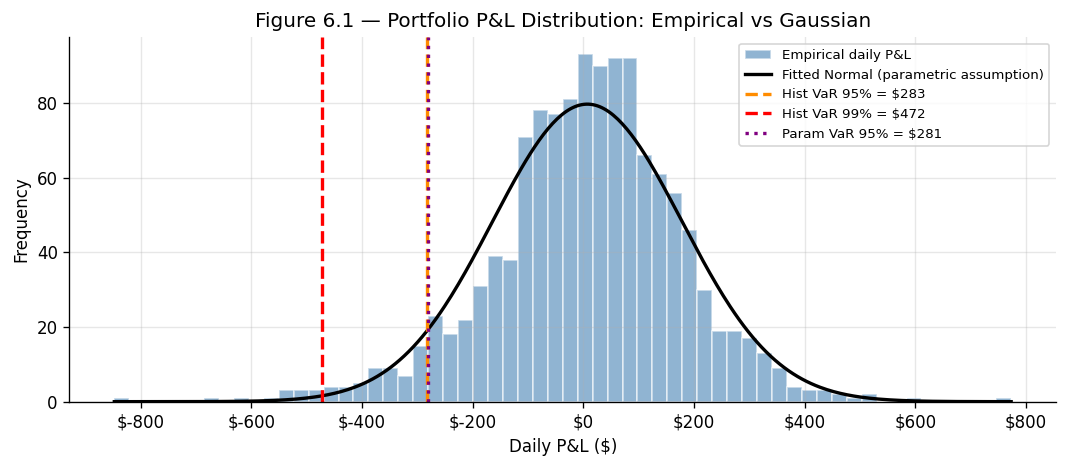

(<Figure size 1080x480 with 1 Axes>,
 <Axes: title={'center': 'Figure 6.1 — Portfolio P&L Distribution: Empirical vs Gaussian'}, xlabel='Daily P&L ($)', ylabel='Frequency'>)

In [14]:
plot_pnl_distribution(engine, hist_var_95, hist_var_99, para_var_95)

**Interpretation.**

- **At the 1-day horizon, all three methods agree within $10** — Historical $283, Parametric $281, Monte Carlo $274. This convergence validates the delta-normal portfolio return construction: the empirical, parametric, and simulated estimates all see the same risk for daily limit monitoring.

- **At 10-day 99%, the methods diverge by $250 (~20%)** — Historical reports $1,492, Parametric $1,258, MC $1,241. This is the **fat-tail signature** widening as both horizon and confidence increase. Parametric and MC underestimate longer-horizon tail risk because they assume normality; Historical captures the realised extreme observations directly and is closer to the truth for stress applications.

- **Bootstrap confidence interval on 1-day 95% Historical VaR: [$264, $313], width $49 — 17.4% of the point estimate.** This quantifies our sampling uncertainty directly: a different 5-year window of history could plausibly have produced a VaR estimate anywhere in this range. The CI width scales with √T as expected (10-day 95% CI: [$834, $990], also ~17% wide).

- **Expected Shortfall (CVaR) at 1-day 95% is $398 — 41% larger than the corresponding VaR of $283.** ES answers a sharper question: *given* that the day's loss exceeds the VaR threshold, what's the *average* loss? The 41% uplift is the textbook empirical equity fat-tail signature — losses in the bad-day region are systematically larger than the threshold suggests. **ES is the number a desk uses for capital planning; VaR is the number used for daily monitoring.**

- **Visible in the P&L histogram (Figure 6.1):** the empirical distribution is roughly bell-shaped but with a clearly fat left tail. The black curve is the Normal that parametric VaR assumes, and note how the empirical bars sit *outside* it in the left tail, the visual signature of the non-normality parametric VaR cannot capture. The single observation near −$800 is a real historical day captured by Historical VaR but invisible to Parametric — exactly the kind of event the normal-distribution assumption misses.

---
## 7. Scenario Analysis

Full revaluation under a grid of simultaneous spot and rate shocks.  
Each cell shows P&L relative to the base portfolio value.

In [15]:
sc_df = build_scenario_table(engine)

print("Table 7.1 — Named Scenario Analysis")
print(sc_df.to_string(index=False))

Table 7.1 — Named Scenario Analysis
                Scenario Spot Shock Rate Shock (bps)  Portfolio Value ($)  P&L ($) P&L (%)
               Base Case        +0%               +0             16409.68     0.00  +0.00%
      Bull Market (+10%)       +10%               +0             17998.44  1588.76  +9.68%
      Bear Market (-10%)       -10%               +0             14894.17 -1515.51  -9.24%
            Crash (-20%)       -20%               +0             13460.59 -2949.09 -17.97%
       Rate Hike +100bps        +0%             +100             16400.40    -9.28  -0.06%
        Rate Cut -100bps        +0%             -100             16419.64     9.96  +0.06%
Stagflation (-5%,+50bps)        -5%              +50             15635.58  -774.10  -4.72%
  Risk-off (-15%,-50bps)       -15%              -50             14176.04 -2233.64 -13.61%


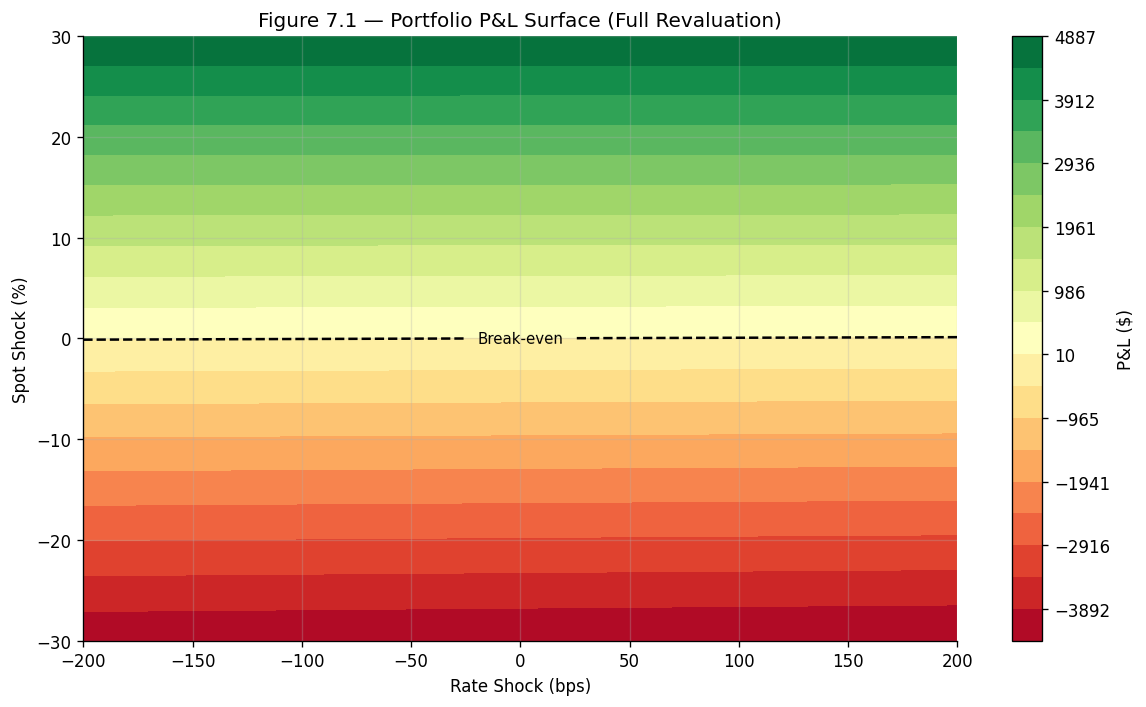

(<Figure size 1200x720 with 2 Axes>,
 <Axes: title={'center': 'Figure 7.1 — Portfolio P&L Surface (Full Revaluation)'}, xlabel='Rate Shock (bps)', ylabel='Spot Shock (%)'>)

In [16]:
plot_pnl_surface(engine)

**Interpretation.**

Each scenario revalues every position through its native pricer — Black-Scholes for European, binomial for American, Monte Carlo for the barrier put — not via delta approximation. This is the section where the option overlay's true protection value becomes visible.

- **Crash (−20%) loses $2,949 (−17.97%).** A pure linear-delta prediction would give $15,541 × (−0.20) = **−$3,108**. The portfolio loses **$159 less** than linear predicts. This gap is the BHP barrier put activating: at −20% uniform shock, BHP reaches its 80% barrier exactly, the down-and-in knocks in, and the put pays out. This is the "cheap disaster insurance" thesis materialising — the barrier sits at the boundary of routine moves and stress moves *by design*.

- **Bull Market (+10%) gains $1,589 (+9.68%);  Bear Market (−10%) loses $1,516 (−9.24%).** The asymmetry is real but small ($73 of asymmetry on ~$1,550 of P&L = ~5%). Most of the asymmetry comes from the protective NAB put losing time value on the upside while gaining intrinsic value on the downside. At ±10%, the barrier is well away from activation, so the asymmetric protection it provides is not yet contributing.

- **Rate Hike (+100bps) costs $9; Rate Cut (−100bps) gains $10.** Rate sensitivity is essentially zero at this scale, by construction: equity positions have no direct rate sensitivity, and the option layer's rate sensitivities are small and largely offset. Rate risk is a second-order concern for this book — confirming the delta+vega exposure dominates.

- **Stagflation (−5% spot, +50bps rate) loses $774 (−4.72%).** Less severe than Bear Market −10% alone, because the smaller spot shock dominates the small adverse rate move. This validates the previous point: spot risk is first-order, rate risk is second-order.

- **Risk-off (−15% spot, −50bps rate) loses $2,234 (−13.61%).** A reasonable approximation of a "flight-to-quality" macro state: equity sells off, central bank cuts rates in response. The rate cut adds ~$10 of relief; the rest is the equity drawdown plus partial offset from the protective puts which are now meaningfully ITM at −15%.

**The P&L surface (Figure 7.1).**

The contour plot visualises portfolio P&L across the full ±30% spot × ±200bps rate grid. Three observations:

- **The bands are nearly horizontal** — colour transitions track spot shock (vertical axis) almost entirely. Rate shock (horizontal axis) barely shifts the surface. This is the same finding as the rate-hike/cut scenarios above, visualised across the full grid: rate risk is negligible relative to spot risk for this book.
- **The asymmetry between upside and downside is visible** — at +30% the upper region reaches +$4,887 while at −30% the lower region bottoms at −$3,892. Upside slightly outweighs downside in dollar terms, reflecting the protective put cushion below.
- **The break-even line sits exactly at zero spot shock** as expected — no rate-only scenario causes meaningful P&L in either direction.

**The takeaway for a desk head.** This book is **structurally long-biased with calibrated downside protection**. The protective NAB put trims everyday drawdowns; the BHP barrier put kicks in at stress levels (−20% or worse) where the equity loss is most painful. Rate risk is negligible. Volatility risk (vega) is positive and additive to the directional view. The book makes money in directionally-favourable markets, loses *less than equity alone* in drawdowns, and adds upside from any volatility expansion regardless of direction.

---
## 8. Head Desk Dashboard

> *"Can I understand the portfolio's risk quickly, and do I trust the modelling workflow?"*  
> — Head Desk question (Lecture 11)

The two tables below give the complete risk summary for a morning briefing.

In [17]:
dash_df = build_risk_dashboard(portfolio, engine, mc_v95, es_95, hist_var_95, para_var_95)

print("Table 9.1 — Head Desk Risk Dashboard")
print(dash_df.to_string(index=False))

Table 9.1 — Head Desk Risk Dashboard
                   Metric      Value
          Portfolio Value $16,409.68
          Portfolio Delta   -11.4563
          Portfolio Gamma    27.4723
           Portfolio Vega  1247.3644
Portfolio Theta (per day)    -0.6897
    Historical VaR 95% 1d    $282.99
    Parametric VaR 95% 1d    $281.22
   Monte Carlo VaR 95% 1d    $273.67
Expected Shortfall 95% 1d    $397.94


In [18]:
dd_df = build_dollar_delta_table(portfolio)

print("Table 9.2 — Dollar Delta Exposure by Underlier")
print(dd_df.to_string(index=False))

Table 9.2 — Dollar Delta Exposure by Underlier
Underlier Dollar Delta ($)
   NAB.AX        $7,375.44
   BHP.AX        $7,873.96
   CSL.AX          $275.41
   WOW.AX           $16.87


**Summary for the desk head.**

- **The book is structurally long-biased with calibrated downside protection.** Total delta-dollar exposure is $15,541, split almost equally between NAB ($7,375) and BHP ($7,874) — the two large equity positions are the dominant P&L drivers. CSL contributes $275 of delta-dollars from its tactical call; WOW contributes essentially zero, confirming the straddle is operating as designed (long-vol with no directional bias).

- **The NAB American protective put is the daily-monitoring hedge.** It trims drawdowns on the largest single-name exposure under everyday spot moves; its early-exercise premium is the architectural reason to use the binomial pricer.

- **The BHP down-and-in barrier put is the tail-event hedge.** It activates only when BHP falls to or below 80% of spot — a sharp drawdown — providing cheap insurance against exactly the kind of move that hurts a long-commodity book the most. The Section 7 crash scenario triggers it directly and shows the protection materialising.

- **1-day 95% VaR is $283 (historical), $281 (parametric), $274 (Monte Carlo).** The three methods converge for daily monitoring, confirming the delta-normal portfolio return construction is internally consistent. Bootstrap CI [$264, $313] quantifies sampling uncertainty at 17% of the point estimate.

- **Expected Shortfall (CVaR) of $398 — 41% larger than VaR — is the number for capital planning.** ES captures *how bad* the bad days are, not just *how often* they happen, which is what the empirical fat-tail signature in the daily P&L histogram makes visible.

- **Portfolio vega is +$12.47 per +1% vol shift.** A volatility expansion benefits the book regardless of direction — the deliberate consequence of layering long calls, long puts, and a long barrier in equal measure on the option overlay.

---
# 9. Limitations & Extensions

Before this platform is trusted for live decisions, the desk should understand exactly what it captures and what it does not. This section is deliberately honest about the four most material limitations and the four highest-priority extensions that would close them.

## 9.1 Limitations

- **Constant volatility per underlying.** Each option is priced with a single historical sigma estimated from 5 years of daily returns. We do not model a volatility surface — no smile, no skew, no term structure. This matters most for the BHP down-and-in barrier put, which is genuinely sensitive to downside skew that historical-vol pricing misses. Our barrier put valuation should be read as a lower bound on its real-market value.

- **No dividend yield in option pricing.** Our pricers assume q = 0, which systematically understates puts and overstates calls for dividend-paying underlyings. This is most material for the NAB American protective put — NAB pays a ~5% trailing dividend yield, which both reduces the option's call equivalent and creates a real early-exercise premium that our q=0 American put cannot capture. We chose to leave this as a documented gap rather than carry the architectural risk of propagating a new parameter through three pricers and re-validating their outputs mid-build. The extension itself is mechanical: add q to the Derivative base class, modify the BS, binomial, and MC pricers' drift terms, and the rest of the platform inherits the change unchanged. Approximately half a day's work plus a full validation re-run.

- **VaR is silent about tail losses, and our window misses the worst recent crisis.** A 99% VaR tells us the boundary; it says nothing about losses *beyond* it. We complement VaR with Expected Shortfall (~41% larger at the 95% level) and with seven deterministic scenarios in Section 7. Even so, our historical sample window (May 2021–May 2026) sits *after* the March 2020 COVID drawdown — so a genuine systemic-stress event on that scale is not represented in our return distribution. The numbers are robust under normal and moderate-stress conditions; they degrade in genuine crises, and the desk should not treat 99% VaR as a worst-case bound.

- **Snapshot, not dynamic.** All Greeks, VaR, and scenario outputs are computed at a single point in time. The platform does not simulate re-hedging, so the implicit assumption is that today's risk profile holds. In reality, Greeks evolve continuously as the market moves — a delta-flat position today is directional tomorrow as the underlying drifts. This is a snapshot tool for end-of-day risk reporting, not a dynamic risk simulator.

## 9.2 Extensions

In priority order for moving toward production:

1. **Dividend yield parameter (q).** Extend the Derivative base class and all three pricers (BS, binomial, MC) to accept a continuous dividend yield. Closes the systematic mispricing on dividend-paying underlyings — material for all four ASX tickers in this book. Half a day's work; implementation is mechanical, the validation is the cost.

2. **Full-revaluation VaR.** Historical and Parametric VaR currently use a delta-normal weighting that ignores option non-linearity. Replace with a full revaluation under each historical scenario — every option re-priced through its native engine. Computationally expensive (~1,264 days × MC reprice of the barrier put dominates), but eliminates the linearisation error quantified in Section 5.3. The single largest accuracy improvement available.

3. **Implied volatility calibration.** Solve for the sigma that matches observed market option prices, and use that as the forward-vol estimate rather than the historical realised sigma. Most material for the barrier put, which is sensitive to downside skew. Requires a root-finder around Black-Scholes for the calibration step; the rest of the engine inherits the new sigma without modification.

4. **Richer scenario library with cross-Greek shocks.** Current scenarios are single-axis shocks (spot, rate, or combined spot+rate). Real desks also stress non-parallel curve moves (steepener/flattener), vol-up-with-spot-down (the classic crash combination), and run stressed-VaR by re-running historical VaR on the worst 250-day window in the sample. The `scenario_analysis` API is already extensible; this is mostly a question of defining the right shock library.